1.6933921591735037
79.14782466520256
[0.3902516230917189, 0.06816469418811372, 0.03858293455769809, 0.03936114164694637]
[0. 0. 0. 0. 0.]
1.3485853704409285
122
122


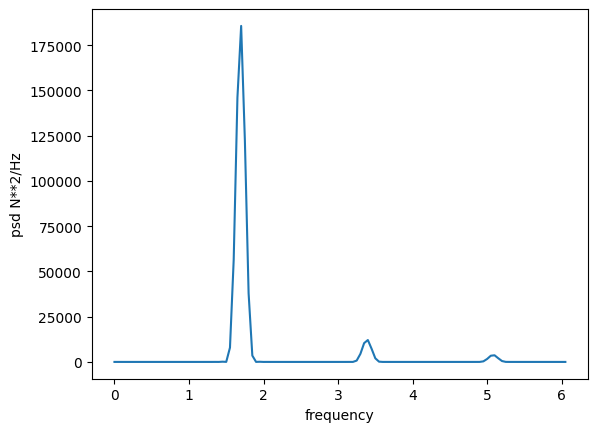

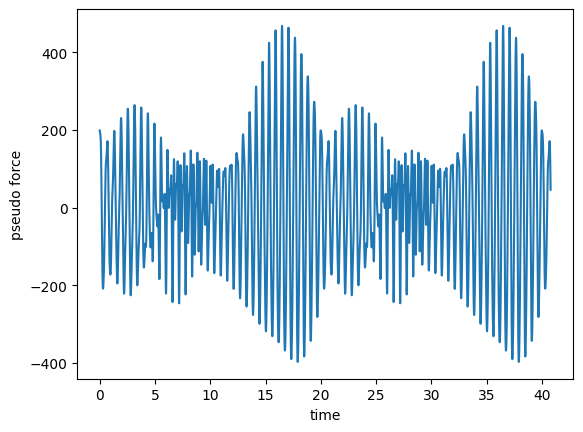

: 

In [3]:
import math
import numpy as np
import random
from matplotlib import pyplot as plt
from pedestrian import *
from scipy.signal import welch,periodogram
from solver import Newmarkpseudo_HSI, Phi_matrix,accdyn_super
from matrix import bridge
from pseudo_excitation import *

#step 1 setup beam and pedestrians

#beam

length = 50  # L - Length (m)
width = 2  # b - Width (m)
height = 0.6  # h - Height (m)
E = 200e9  # E - Young's modulus (N/m^2)
modalDampingRatio = 0.005  # xi - Modal damping ratio of the beam
nHigh = 3  # nHigh - Higher mode for damping matrix
beamFreq =2 #Hz
area = 0.3162  # A - Cross-section area (m^2)
linearMass = 500  # m - Linear mass (kg/m)
x_interested= length/2
numbers = 3

#ped
numped = 1
pedmass = 80    #kg
peddamp = .3    
#pedstiff = 25000 #N/m
pedpace  = 2     #Hz
pedphase = 0
pedInlocation = 0
pedvelocity = 1.25
pedBodyF= 2 #Hz

#ped
kped=(2*np.pi*pedBodyF)**2*pedmass
cped = (2*np.pi*pedBodyF)*2*peddamp*pedmass

modulus =linearMass * ((2 * math.pi * beamFreq) * (math.pi / length) ** (-2)) ** 2  #E*(width*height**3)/12

#set time info
hht=0.01

#initial possition vector.......formultiple ped all these would become matrices

#xrb=np.zeros(1,numped)
xrb=[0]

Bridge = bridge(   
    length = length,                 # m
    modulus = modulus,               # N m^2
    density = linearMass,            # kg/m
    damp    = modalDampingRatio ,    #%
    numbers = 3,  )                   #modes


N_bridge = 3




# probabilitstic parameters
mean_pace = 2 #Hz  2005 pachi
pace_COV = 0.1

mean_mass= pedmass #kg
mass_COV= 0.17 #from butz 2008

mean_velocity = 1.3
std_velocity = 0.12 #pachi 2005

mean_alpha = np.array([0.41 * (mean_pace - 0.95),
                0.069 + 0.0056 * mean_pace,
                .033 + 0.0064 * mean_pace,
                0.013 + 0.0065 *mean_pace])

alpha_COV= np.array([0.17,0.4,0.4,0.4])


alpha_std = mean_alpha*alpha_COV

# Generate a random variable from a normal distribution with considered mean and std_dev from literiture

randomPace = random.gauss(mean_pace, pace_COV*mean_pace)
randomMass = random.gauss(mean_mass, mass_COV*mean_mass)
randomAlpha = [random.gauss(mean_alpha[i], alpha_std[i]) for i in range(len(alpha_COV))]
#randomPhase = [random.uniform(0, 2 * math.pi) for i in range(len(mean_alpha)+1)]
randomVelocity = random.gauss(mean_velocity,std_velocity)
randomPhase = np.zeros(5)


print(randomPace)
print(randomMass)
print(randomAlpha)
print(randomPhase)
print(randomVelocity)

t = np.array(np.arange(0, (length+1) / pedvelocity, hht))   #for the testing length was made 10

'''Human = Pedestrian(
         mass = pedmass,     #kg
         damp = peddamp ,   #%
         stiff = kped, #N/m
         pace  = pedpace ,    #Hz
         phase = pedphase,
         location = pedInlocation,
         velocity = pedvelocity,
         
         iSync=0)'''


Human = Pedestrian(
         mass = randomMass,     #kg
         damp = peddamp ,   #%
         stiff = kped, #N/m
         pace  = randomPace ,    #Hz
         phase = randomPhase,
         location = pedInlocation,
         velocity = randomVelocity,
         
         iSync=0)

#ped = RandPedestrian(randomMass, randomPace, randomPhase, randomAlpha)
n=1
numped=1
#j=np.size(t)
xr=[0]
#force_at_time_t = np.zeros(np.size(t))

#F=np.zeros((N_bridge,np.size(t)))
#for i in range (np.size(t)):
     
force_at_time_t = calcPedForce(Human,t)

fs=1/hht
frequencies, psd = welch(force_at_time_t, fs=fs,nperseg=1000, nfft=2000 )
frequencies = np.array(frequencies)
psd = np.array(psd)
frequencies=frequencies[frequencies<(randomPace*3+1)] #adjust range of frequency range suitable for analysis
psd=psd[:np.size(frequencies)]

print(np.size(frequencies))
print(np.size(psd))

plt.plot(frequencies,psd)
plt.xlabel("frequency")
plt.ylabel("psd N**2/Hz")
plt.show()

pseudo_force = pseudo_force(psd,frequencies,t)
plt.plot(t,pseudo_force)
plt.xlabel("time")
plt.ylabel("pseudo force")
plt.show()


In [2]:
real,imaginary = pseudo_excitation(psd,frequencies,50,1.25,t)
plt.plot(t.flatten(),real[[20],:].T)
plt.xlabel("time")
plt.ylabel("real force")
plt.show()

plt.plot(t.flatten(),imaginary[[20],:].T)
plt.xlabel("time")
plt.ylabel("real force")
plt.show()


NameError: name 'pseudo_excitation' is not defined

[[ 0.00000000e+00  3.44172798e-05  6.82504645e-05 ... -5.66584551e-05
  -8.82529535e-05  0.00000000e+00]
 [ 0.00000000e+00  6.48877880e-05  1.14085103e-04 ... -2.49761124e-05
  -7.47502922e-05  0.00000000e+00]
 [ 0.00000000e+00  7.79613941e-05  7.97184757e-05 ... -3.22659114e-05
  -4.80470355e-05  0.00000000e+00]
 [ 0.00000000e+00  1.11805816e-10  7.80676419e-10 ... -2.19189523e-09
  -2.14005533e-09  0.00000000e+00]]
[[ 0.00000000e+00  4.11896617e-05  8.16798877e-05 ... -6.78803167e-05
  -1.05764552e-04  0.00000000e+00]
 [ 0.00000000e+00  7.76559346e-05  1.36533173e-04 ... -2.98887355e-05
  -8.94651635e-05  0.00000000e+00]
 [ 0.00000000e+00  9.33020698e-05  9.54039764e-05 ... -3.86149599e-05
  -5.75027417e-05  0.00000000e+00]
 [ 0.00000000e+00  1.33806151e-10  9.34289602e-10 ... -2.63491278e-09
  -2.57326746e-09  0.00000000e+00]]
[[ 0.00000000e+00  2.40889095e-05  4.77680555e-05 ... -3.98269186e-05
  -6.21109864e-05  0.00000000e+00]
 [ 0.00000000e+00  4.54154442e-05  7.98472169e-05 ...

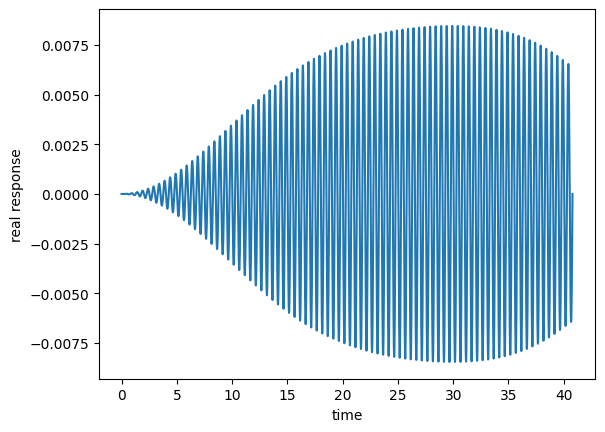

In [16]:
Real_responce = np.zeros((np.size(frequencies),np.size(t)))
for i in range(np.size(frequencies)):
    realF=np.array(real[[i],:])
    #print(realF)
    _,_,ddu = Newmarkpseudo_HSI(Human, Bridge,numped,N_bridge,length,hht,pedvelocity,[pedmass],[kped],[cped],[0],linearMass,realF)
    #case_pedestrian,case_bridge,numped,N_bridge, lb, hht, v, mped,kped,cped,xrb, rho,force
    Real_responce[[i],:]=accdyn_super(Bridge,ddu,x_interested,hht)

plt.plot(t.flatten(),Real_responce[[40],:].T)
plt.xlabel("time")
plt.ylabel("real response")
#plt.savefig("plot.png",dpi=300Z)
plt.show()
#plt.semilogy(frequencies,psd)


In [17]:
import pickle
with open('Real_responce_random1.pkl', 'wb') as f:
    pickle.dump(Real_responce, f)

print("Matrix saved to Real_responce_random1.pkl")

Matrix saved to Real_responce_random1.pkl


[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
[[0.00000000e+00 0.00000000e+00 2.58801770e-07 ... 1.55936887e-05
  1.51671891e-05 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 4.87925220e-07 ... 1.77033629e-06
  1.58251751e-06 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 5.86231599e-07 ... 3.70115583e-07
  1.27486484e-07 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.68144798e-12 ... 9.70338199e-11
  6.51048264e-11 0.00000000e+00]]
[[0.00000000e+00 0.00000000e+00 3.02708078e-07 ... 1.83083847e-05
  1.78080001e-05 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 5.70702841e-07 ... 2.07117618e-06
  1.85147173e-06 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 6.85687121e-07 ... 4.32930892e-07
  1.49128571e-07 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.96670944e-12 ... 1.15197246e-10
  7.75821138e-11 0.00000000e+00]]
[[0.00000000e+00 0.00000000e+00 1.54539277e-07 ... 9.40616162e-06
  9.14939485e-06 0.00000000e+00]
 [0.00

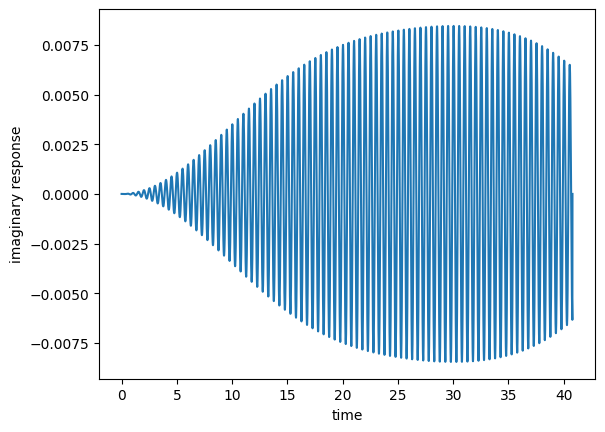

In [18]:
imag_responce = np.zeros((np.size(frequencies),np.size(t)))
for i in range(np.size(frequencies)):
    imagF=np.array(imaginary[[i],:])
    #print(realF)
    _,_,ddu = Newmarkpseudo_HSI(Human, Bridge,numped,N_bridge,length,hht,pedvelocity,[pedmass],[kped],[cped],[0],linearMass,imagF)
    #case_pedestrian,case_bridge,numped,N_bridge, lb, hht, v, mped,kped,cped,xrb, rho,force
    imag_responce[[i],:]=accdyn_super(Bridge,ddu,x_interested,hht)



plt.plot(t.flatten(),imag_responce[[40],:].T)
plt.xlabel("time")
plt.ylabel("imaginary response")
#plt.savefig("plot.png",dpi=300Z)
plt.show()
#plt.semilogy(frequencies,psd)   


In [19]:
import pickle
with open('imag_responce_random1.pkl', 'wb') as f:
    pickle.dump(imag_responce, f)

print("Matrix saved to imag_responce_random1.pkl")

Matrix saved to imag_responce_random1.pkl


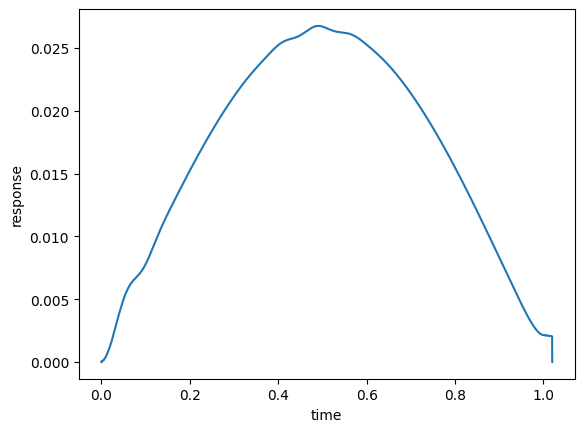

In [20]:
with open('Real_responce_random1.pkl', 'rb') as f1:
    Real_responce_random1 = pickle.load(f1)
with open('imag_responce_random1.pkl', 'rb') as f2:
    imag_responce_random1 = pickle.load(f2)

Y=np.zeros((1,np.size(t)))
delta_f= frequencies[5]-frequencies[4]
for i in range(np.size(t)):
    for j in range(np.size(frequencies)):
        Y[0,[i]] += (Real_responce_random1[[j],[i]]**2 + imag_responce_random1[[j],[i]]**2)*delta_f

random_RMS=np.sqrt(Y)
Xnormal=pedvelocity*t/length

plt.plot(Xnormal.flatten(),random_RMS.T)
plt.xlabel("relative possition")
plt.ylabel("response")

plt.show()

In [21]:
import pickle
with open('COV0.1_RMS.pkl', 'wb') as f:
    pickle.dump(random_RMS, f)

print("Matrix saved to COV0.1_RMS.pkl")

Matrix saved to COV0.1_RMS.pkl


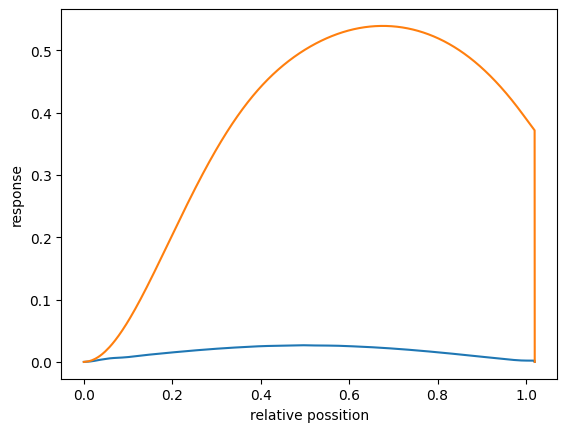

In [22]:
with open('COV0.1_RMS.pkl', 'rb') as f1:
    RMS_COV = pickle.load(f1)
with open('deterministic_RMS.pkl', 'rb') as f2:
    deterministic_RMS = pickle.load(f2)

plt.plot(Xnormal.flatten(),RMS_COV.T)
plt.plot(Xnormal.flatten(),deterministic_RMS.T)
plt.xlabel("relative possition")
plt.ylabel("response")

plt.show()